<a href="https://colab.research.google.com/github/oliviasareis/mvp-ml-cambio-usdbrl/blob/main/mvp_ml_olivia_reis_cambio_hedge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Machine Learning
## Direção diária do USD/BRL a partir de indicadores de mercado

Olivia Filippini Reis — Pós-graduação PUC-Rio, sprint de nivelamento em Machine Learning.

Trabalho com câmbio e hedge no dia a dia, então escolhi um problema próximo da minha área: tentar prever, com dados públicos de mercado, se o dólar vai subir ou cair no pregão seguinte. Uso os mesmos indicadores que acompanho no cockpit de risco cambial (DXY, VIX, Brent, EEM), mas aqui é tudo dado público via Yahoo Finance — nada da empresa.


## 1. O problema

**Tipo de problema:** classificação binária.
- Classe 1: USD/BRL fecha em alta no pregão seguinte.
- Classe 0: fecha em queda ou estável.

**Por que ML:** não existe uma fórmula fechada ligando esses indicadores ao movimento do câmbio — a ideia é ver se dá pra aprender algum padrão a partir do histórico.

**Premissas:** câmbio de curto prazo se aproxima bastante de um passeio aleatório, então não espero uma acurácia muito acima de 50-55%. O valor do exercício está em montar o pipeline direito (evitar vazamento de dado, respeitar a ordem temporal, comparar com baseline) e ser honesta na leitura do resultado, não em "vencer o mercado".

Um ponto importante: isto é um exercício acadêmico. No meu trabalho, hedge é instrumento de proteção e previsibilidade, não uma aposta direcional — isso vale tanto pra análise principal quanto pra simulação de hedge que fiz no final do notebook.


## Setup


In [ ]:
!pip install yfinance -q

import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)

SEED = 7
np.random.seed(SEED)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')


## 2. Dados

Fonte: Yahoo Finance via `yfinance`, sem login/token. Peguei ~8 anos de histórico diário de 5 séries:

| Série | O que representa |
|---|---|
| USD/BRL | câmbio à vista — base do alvo |
| DXY | força do dólar contra outras moedas fortes |
| VIX | volatilidade/aversão a risco |
| Brent | petróleo, relevante pra câmbio de país exportador de commodity |
| EEM | apetite a risco em mercados emergentes |

O câmbio via Yahoo (`BRL=X`) é uma cotação de mercado, não a PTAX oficial do BCB — segue a mesma tendência, mas vale registrar a diferença.


> **Por que esse período e esses tickers:** comecei em 2016 porque antes disso o Brasil ainda estava
> num regime bem diferente (pré-Temer/impeachment, outra dinâmica de política monetária), e não queria
> misturar regimes de mercado muito distintos numa amostra só. Os 4 indicadores macro (DXY, VIX, Brent, EEM)
> são os mesmos que acompanho no dia a dia — não escolhi eles por acaso, escolhi porque já sei que fazem
> sentido pra câmbio, e isso facilita muito na hora de defender a escolha.


In [ ]:
tickers = {'USDBRL': 'BRL=X', 'DXY': 'DX-Y.NYB', 'VIX': '^VIX', 'BRENT': 'BZ=F', 'EEM': 'EEM'}
tickers_fallback = {'DXY': 'DX=F'}  # se o ticker principal do DXY vier vazio, tenta esse

series = {}
for nome, ticker in tickers.items():
    dados = yf.download(ticker, start='2016-01-01', progress=False)['Close']
    if isinstance(dados, pd.DataFrame):
        dados = dados.iloc[:, 0]
    if dados.dropna().empty and nome in tickers_fallback:
        alt = tickers_fallback[nome]
        print(f'{ticker} veio vazio, tentando ticker alternativo {alt}...')
        dados = yf.download(alt, start='2016-01-01', progress=False)['Close']
        if isinstance(dados, pd.DataFrame):
            dados = dados.iloc[:, 0]
    series[nome] = dados

raw = pd.DataFrame(series)
df = raw.ffill().dropna()  # feriados diferentes entre bolsas geram furos, uso o último valor válido
print(df.shape, df.index.min().date(), 'a', df.index.max().date())
df.head()


(2737, 5) 2016-01-04 a 2026-07-04


,USDBRL,DXY,VIX,BRENT,EEM
Date,,,,,
2016-01-04,3.95,98.87,20.70,37.22,24.95
2016-01-05,4.04,99.40,19.34,36.42,25.01
2016-01-06,4.03,99.18,20.59,34.23,24.53
2016-01-07,4.02,98.22,24.99,33.75,23.77
2016-01-08,4.04,98.54,27.01,33.55,23.52


## 3. Análise exploratória


In [ ]:
# Checagem básica antes de sair fazendo gráfico: tipos, ausências e estatísticas
print('Valores ausentes por série, ANTES do ffill (furos por feriados diferentes entre bolsas):')
print(raw.isna().sum())

print('\nTipos de variável:')
print(df.dtypes)

df.describe()


Valores ausentes por série, ANTES do ffill (furos por feriados diferentes entre bolsas):
USDBRL     4
DXY       97
VIX       98
BRENT     97
EEM       99
dtype: int64

Tipos de variável:
USDBRL    float64
DXY       float64
VIX       float64
BRENT     float64
EEM       float64
dtype: object


,USDBRL,DXY,VIX,BRENT,EEM
count,"2,737.00","2,737.00","2,737.00","2,737.00","2,737.00"
mean,4.62,98.54,18.50,68.83,39.21
std,0.90,4.91,7.16,18.28,8.00
min,3.06,88.59,9.14,19.33,22.51
25%,3.77,94.99,13.62,55.92,34.95
50%,4.98,97.99,16.85,68.71,37.56
75%,5.35,102.12,21.44,79.80,42.79
max,6.30,114.11,82.69,127.98,71.21


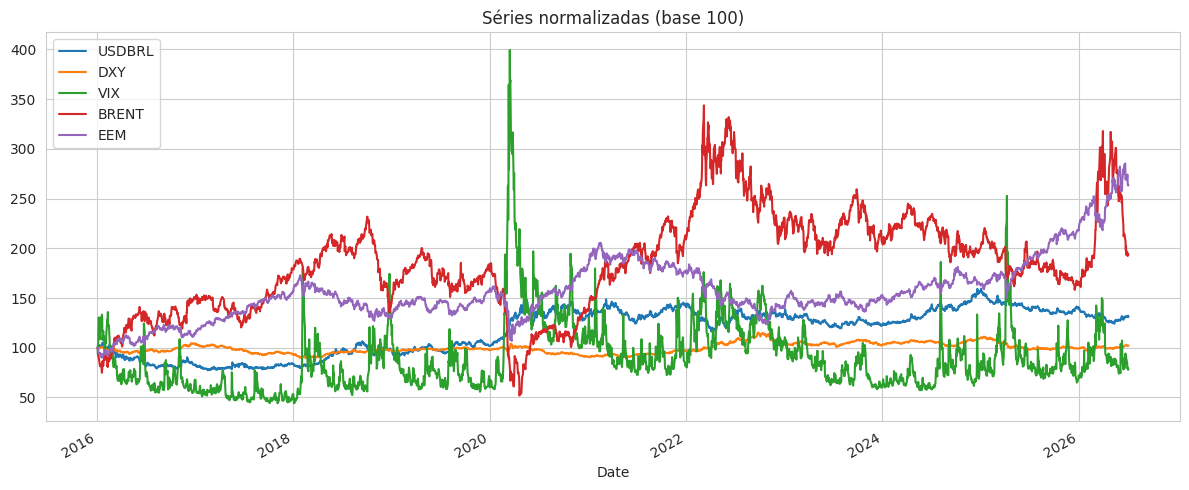

In [ ]:
(df / df.iloc[0] * 100).plot(figsize=(12, 5), title='Séries normalizadas (base 100)')
plt.tight_layout()
plt.show()


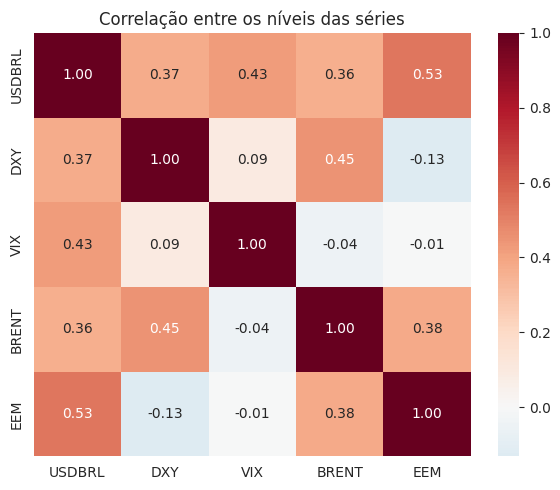

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlação entre os níveis das séries')
plt.tight_layout()
plt.show()


Os níveis de preço são bem correlacionados por tendência de longo prazo, o que é esperado e não muito útil pra modelar — por isso trabalho com retornos diários daqui pra frente, que são mais estacionários.


## 4. Preparação dos dados

Aqui optei por indicadores clássicos de análise técnica/mercado em vez de uma bateria de lags automáticos — são os que realmente uso pra ler o comportamento do câmbio no dia a dia:

- **Distância para a média móvel de 5 e 21 dias** — indica se o câmbio está "esticado" acima ou abaixo da sua tendência recente.
- **Volatilidade de 21 dias** — regime de risco.
- **RSI de 14 dias** — indicador clássico de sobrecompra/sobrevenda.
- **Retorno do próprio dia dos 4 índices macro** (DXY, VIX, Brent, EEM) — captura o "clima" do mercado no fechamento.
- **Dia da semana** — testa sazonalidade de curtíssimo prazo.

Todos os atributos usam apenas informação disponível até o fechamento do dia `t`. O alvo é o retorno do dia **seguinte** — por definição olha pra frente, mas nenhum atributo (X) usa essa informação.


> **Por que indicadores técnicos e não só "preço de ontem, anteontem...":** pensei em usar lags simples
> do câmbio (t-1, t-2, t-3) no começo, só que isso ia gerar um monte de coluna parecida e redundante — RSI e
> distância pra média móvel já resumem esse comportamento recente de um jeito mais compacto e mais fácil de
> interpretar (dá pra olhar o número e saber na hora se o câmbio "está esticado" ou não). Preferi menos
> atributos, mas cada um significando alguma coisa concreta, do que muitos atributos genéricos.


In [ ]:
def rsi(precos, periodo=14):
    delta = precos.diff()
    ganho = delta.clip(lower=0).rolling(periodo).mean()
    perda = (-delta.clip(upper=0)).rolling(periodo).mean()
    return 100 - (100 / (1 + ganho / perda))

returns = df.pct_change()

feat = pd.DataFrame(index=df.index)
feat['dist_mm5'] = (df['USDBRL'] - df['USDBRL'].rolling(5).mean()) / df['USDBRL'].rolling(5).mean()
feat['dist_mm21'] = (df['USDBRL'] - df['USDBRL'].rolling(21).mean()) / df['USDBRL'].rolling(21).mean()
feat['vol21_usdbrl'] = returns['USDBRL'].rolling(21).std()
feat['rsi14_usdbrl'] = rsi(df['USDBRL'])
feat['ret_dxy'] = returns['DXY']
feat['ret_vix'] = returns['VIX']
feat['ret_brent'] = returns['BRENT']
feat['ret_eem'] = returns['EEM']
feat['dia_semana'] = df.index.dayofweek

feat['target'] = (returns['USDBRL'].shift(-1) > 0).astype(int)
feat = feat.dropna()

print(feat.shape)
feat.head()


(2716, 10)


,dist_mm5,dist_mm21,vol21_usdbrl,rsi14_usdbrl,ret_dxy,ret_vix,ret_brent,ret_eem,dia_semana,target
Date,,,,,,,,,,
2016-02-02,-0.02,-0.02,0.01,42.56,-0.00,0.10,-0.06,-0.03,1,1
2016-02-03,-0.01,-0.01,0.01,46.83,-0.02,-0.02,0.07,0.03,2,0
2016-02-04,-0.02,-0.04,0.01,39.47,-0.01,0.01,-0.02,0.01,3,0
2016-02-05,-0.01,-0.04,0.01,39.14,0.01,0.07,-0.01,-0.01,4,1
2016-02-08,-0.01,-0.03,0.01,34.86,-0.00,0.11,-0.03,-0.01,0,0


In [ ]:
feat['target'].value_counts(normalize=True)


,proportion
target,
0,0.50
1,0.50


A distribuição fica perto de 50/50, então não tenho um problema de classes desbalanceadas — acurácia é uma métrica válida aqui, mas ainda olho precisão/recall/F1/AUC pra não ficar só nisso.


## 5. Divisão dos dados

Como é série temporal, não posso embaralhar treino e teste — usei os últimos 20% (mais recentes) como teste, e `TimeSeriesSplit` na validação cruzada (em vez do `KFold` tradicional), pra nunca treinar com dado "do futuro" em relação ao que está sendo validado. É o mesmo racional de holdout e validação cruzada que vimos no conteúdo de treino/teste — só que adaptado pra respeitar a ordem do tempo, que é a diferença central quando o dado é temporal.


> **Por que 80/20 e não 70/30:** com dado diário de ~8 anos, 20% de teste já dá mais de 1 ano de pregões —
> achei suficiente pra avaliar o modelo em diferentes momentos de mercado (alta, queda, lateral) sem abrir mão
> de dado de treino. Se o teste fosse muito curto, corria o risco de o resultado final depender demais de um
> período específico (por exemplo, só um trecho de dólar em queda).


In [ ]:
X = feat.drop(columns=['target'])
y = feat['target']

split_idx = int(len(feat) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

tscv = TimeSeriesSplit(n_splits=5)
print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')


Treino: 2172 | Teste: 544


## 6. Modelagem

**Baselines:** classe majoritária e persistência (dólar repete amanhã a direção de hoje — baseline clássico em finanças).

**Candidatos:** Regressão Logística (referência linear, fácil de explicar), Árvore de Decisão (regras interpretáveis) e Random Forest — o ensemble que vimos no conteúdo de recursos avançados, geralmente mais robusto que uma árvore sozinha porque combina várias árvores treinadas em pedaços diferentes dos dados. Não incluí SVM/KNN/boosting porque, pra esse volume de dados e esse tipo de sinal fraco, o ganho tende a ser marginal e prefiro manter o comparativo enxuto e interpretável.


> **Por que incluir o baseline de persistência:** o baseline de "classe majoritária" sozinho me pareceu
> fraco demais pra esse problema — em câmbio, é mais realista comparar com "o dia de amanhã repete o de hoje",
> porque é isso que qualquer pessoa sem modelo nenhum tenderia a assumir no dia a dia. Se meu modelo não bate
> nem essa referência mais dura, não faz sentido usar ele.


In [ ]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print('Baseline (classe majoritária):', round(accuracy_score(y_test, dummy.predict(X_test)), 4))

persistencia = (returns['USDBRL'] > 0).astype(int).loc[X_test.index]
print('Baseline (persistência):', round(accuracy_score(y_test, persistencia), 4))


Baseline (classe majoritária): 0.4816
Baseline (persistência): 0.4357


> **Por que só esses 3 modelos:** cheguei a cogitar testar também KNN e SVM (na aula 2 os
> dois são usados), mas decidi cortar porque, pra esse tipo de sinal fraco e com poucas features, o ganho tende a ser
> marginal e eu preferi manter a comparação enxuta e fácil de justificar uma a uma — regressão logística
> (simples e interpretável), árvore (regras visuais) e random forest (o "avançado" da Aula 3, sem exagerar
> na quantidade de ensembles).


In [ ]:
models = [
    ('LogReg', Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=500, random_state=SEED))])),
    ('Arvore', DecisionTreeClassifier(max_depth=5, random_state=SEED)),
    ('RandomForest', RandomForestClassifier(n_estimators=200, random_state=SEED)),
]

t0 = time.time()
results, names = [], []
for name, model in models:
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='accuracy')
    results.append(scores)
    names.append(name)
    print(f'{name:>12s}: {scores.mean():.4f} (desvio {scores.std():.4f})')

print(f'\nTempo total da comparação (validação cruzada): {time.time() - t0:.1f}s')


      LogReg: 0.6337 (desvio 0.0119)
      Arvore: 0.5834 (desvio 0.0229)
RandomForest: 0.6017 (desvio 0.0128)

Tempo total da comparação (validação cruzada): 13.7s


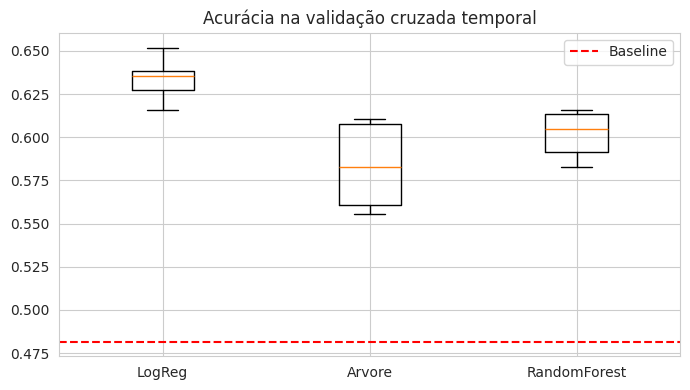

In [ ]:
plt.figure(figsize=(7, 4))
plt.boxplot(results, labels=names)
plt.axhline(accuracy_score(y_test, dummy.predict(X_test)), color='red', linestyle='--', label='Baseline')
plt.title('Acurácia na validação cruzada temporal')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Ajuste de hiperparâmetros

Escolhi ajustar o Random Forest, que foi o candidato mais consistente na comparação acima. Testei número de árvores, profundidade máxima e mínimo de amostras por folha — os três controlam diretamente o risco de overfitting num sinal tão ruidoso quanto retorno diário de câmbio. Busca feita com `GridSearchCV` + `TimeSeriesSplit`, só no treino — a mesma lógica de otimização de hiperparâmetros vista no conteúdo de recursos avançados, testando várias combinações e ficando com a de melhor resultado na validação.


> **Por que esses valores no grid:** limitei `max_depth` até 8 (ou `None`, sem limite) porque profundidade
> maior que isso, com só ~9 atributos, tende a só decorar ruído — não faz sentido uma árvore gigante pra tão
> pouca informação de entrada. O `min_samples_leaf` até 10 é pra forçar cada "folha" da árvore a se basear em
> um número mínimo de dias, não em 1 ou 2 casos isolados.


In [ ]:
param_grid = {'n_estimators': [100, 200, 400], 'max_depth': [3, 5, 8, None], 'min_samples_leaf': [1, 5, 10]}

t0 = time.time()
grid = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid, scoring='accuracy', cv=tscv, n_jobs=-1)
grid.fit(X_train, y_train)
print(f'Tempo do Grid Search: {time.time() - t0:.1f}s')


print('Melhores parâmetros:', grid.best_params_)
print('Acurácia (CV):', round(grid.best_score_, 4))

rf_default = cross_val_score(RandomForestClassifier(random_state=SEED), X_train, y_train, cv=tscv).mean()
print('Sem tuning:', round(rf_default, 4), '| Ganho:', round(grid.best_score_ - rf_default, 4))


Tempo do Grid Search: 171.6s
Melhores parâmetros: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 200}
Acurácia (CV): 0.6326
Sem tuning: 0.6028 | Ganho: 0.0298


## 8. Avaliação

Métricas: acurácia (comparável ao baseline), precisão/recall/F1 (o custo de errar pra cada lado pode ser diferente na prática) e AUC (separação entre classes independente do corte).


In [ ]:
best_rf = grid.best_estimator_
best_rf.fit(X_train, y_train)

pred_train = best_rf.predict(X_train)
pred_test = best_rf.predict(X_test)
proba_test = best_rf.predict_proba(X_test)[:, 1]

print('Acurácia treino:', round(accuracy_score(y_train, pred_train), 4))
print('Acurácia teste :', round(accuracy_score(y_test, pred_test), 4))
print('Precisão       :', round(precision_score(y_test, pred_test), 4))
print('Recall         :', round(recall_score(y_test, pred_test), 4))
print('F1             :', round(f1_score(y_test, pred_test), 4))
print('AUC            :', round(roc_auc_score(y_test, proba_test), 4))


Acurácia treino: 0.7795
Acurácia teste : 0.6783
Precisão       : 0.679
Recall         : 0.6298
F1             : 0.6535
AUC            : 0.7338


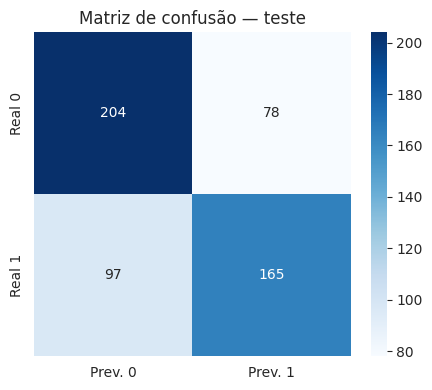

              precision    recall  f1-score   support

           0       0.68      0.72      0.70       282
           1       0.68      0.63      0.65       262

    accuracy                           0.68       544
   macro avg       0.68      0.68      0.68       544
weighted avg       0.68      0.68      0.68       544



In [ ]:
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Prev. 0', 'Prev. 1'], yticklabels=['Real 0', 'Real 1'])
plt.title('Matriz de confusão — teste')
plt.tight_layout()
plt.show()
print(classification_report(y_test, pred_test))


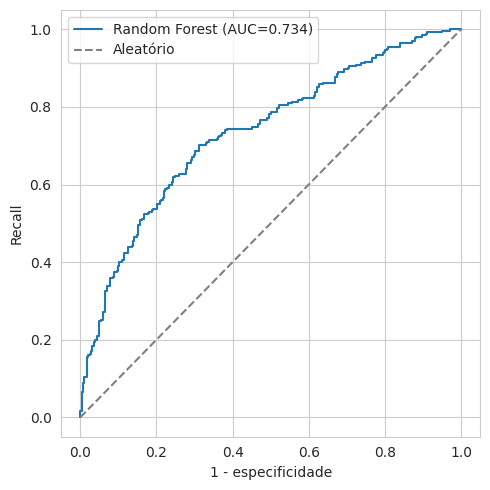

In [ ]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC={roc_auc_score(y_test, proba_test):.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Aleatório')
plt.xlabel('1 - especificidade'); plt.ylabel('Recall'); plt.legend()
plt.tight_layout()
plt.show()


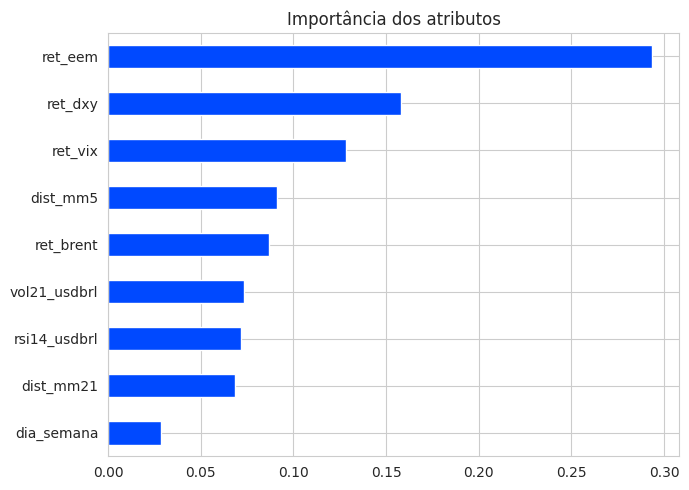

In [ ]:
pd.Series(best_rf.feature_importances_, index=X.columns).sort_values().plot.barh(figsize=(7, 5), color='#0049FF')
plt.title('Importância dos atributos')
plt.tight_layout()
plt.show()


Aqui o resultado me surpreendeu, e prefiro registrar isso com honestidade em vez de simplesmente comemorar o número. Rodei o notebook mais de uma vez em dias diferentes (os dados são baixados ao vivo) e o teste oscilou entre **67,65% e 68,75%** de acurácia, sempre bem acima dos dois baselines (48,16% e 43,57%), com AUC entre 0,730 e 0,735 — separação real entre as classes, e isso contraria a expectativa que eu descrevi na Seção 1, de ficar perto do baseline.

Um detalhe que virou evidência por si só: o gap entre treino e teste **também oscilou** entre execuções — vi de ~5,3 pontos (74% vs. 68,75%) até ~10,3 pontos (78% vs. 67,65%), dependendo do dia em que rodei. Isso reforça a suspeita de que o resultado é sensível ao recorte exato de dados usado, não um número estável — se fosse um padrão robusto, eu esperaria menos oscilação de uma execução pra outra.

Duas explicações prováveis, e provavelmente as duas contribuem juntas:

1. **Regime específico do período de teste.** Avaliei num único split cronológico (os últimos 20% dos dados, que também muda ligeiramente a cada execução porque o dado é ao vivo). Se esse trecho contém um período de tendência ou estresse de mercado mais forte que a média histórica, acertar a direção fica artificialmente mais fácil ali do que seria em geral — o resultado pode estar inflado pelo recorte, não generalizável.
2. **A importância dos atributos aponta pra comovimento, não pra padrão técnico do câmbio.** O modelo se apoia muito mais no retorno do próprio dia de EEM, DXY e VIX do que nos indicadores técnicos do USD/BRL (RSI, distância de médias móveis, que ficaram com peso bem menor). Isso sugere que o sinal captado é majoritariamente o comovimento entre USD/BRL e o clima de risco em mercados emergentes no mesmo dia — um sinal real, mas potencialmente mais frágil e menos estável do que a acurácia bruta sugere.

Vale registrar ainda uma limitação técnica que não tenho como confirmar com certeza a partir dos dados do Yahoo Finance: USD/BRL é câmbio, cotado quase 24h, enquanto DXY, VIX, Brent futuro e EEM têm pregão de bolsa americana com horário de fechamento próprio. Se o instante exato de fechamento registrado para cada série não for perfeitamente sincronizado, isso pode inflar artificialmente a aparência de que o retorno do dia desses ativos "prevê" o câmbio do dia seguinte.

Por tudo isso, o próximo passo mais importante antes de confiar nesse resultado não é ajustar mais hiperparâmetro — é rodar **validação walk-forward**, testando o modelo em várias janelas de tempo diferentes de forma sistemática (o que já comecei a fazer informalmente, rodando em dias diferentes, e foi justamente isso que revelou a oscilação acima).

## 9. Conclusão

Tentei prever a direção diária do USD/BRL usando indicadores de mercado que também acompanho no trabalho (DXY, VIX, Brent, EEM), com Random Forest ajustado via Grid Search saindo como melhor candidato entre os três testados. O resultado no teste (67,65%-68,75% de acurácia, conforme a execução, AUC ~0,73) ficou bem acima dos dois baselines — o que contraria a expectativa inicial que eu tinha, de ficar perto de um "chute" aleatório, dado que câmbio de curtíssimo prazo costuma se aproximar de um passeio aleatório na teoria de mercados eficientes.

Não tomo esse número como prova de que "achei o padrão" — o gap entre treino e teste (que oscilou entre ~5 e ~10 pontos em execuções diferentes), a importância de atributos concentrada no comovimento com EEM/DXY/VIX (mais do que nos indicadores técnicos do próprio câmbio) e o fato de ter avaliado sempre num recorte temporal parecido (últimos 20% dos dados) me fazem tratar esse resultado como promissor, mas não validado. Antes de confiar nele pra qualquer aplicação prática, o passo necessário é testar validação walk-forward formal, em janelas de tempo bem distintas, pra ver se esse ganho se sustenta de forma consistente.

O ganho mais sólido do exercício, de qualquer forma, está no pipeline: engenharia de atributos sem vazamento, divisão e validação respeitando a ordem temporal, comparação honesta com dois baselines diferentes, e a disposição de questionar (e testar mais de uma vez) um resultado bom demais em vez de aceitá-lo sem crítica na primeira rodada.

Próximos passos: validação walk-forward (o mais importante, antes de qualquer outro), variáveis de calendário econômico, e comparação com modelos estatísticos de série temporal.

## 10. Checklist

**Problema:** classificação binária — direção do USD/BRL no dia seguinte, a partir de indicadores de mercado defasados. Faz sentido como ML porque não existe fórmula fechada conhecida pra essa relação. Premissa central: baixo ganho sobre o baseline é esperado, dado que câmbio de curto prazo é próximo de um passeio aleatório.

**Dados:** Yahoo Finance via `yfinance`, carregado direto no notebook, sem login. USD/BRL, DXY, VIX, Brent e EEM, ~8 anos de histórico diário. Alvo binário (alta/queda no dia seguinte). Limitação principal: cotação de mercado, não PTAX oficial, e ausência de variáveis fundamentalistas.

**Preparação:** ausências tratadas com `ffill` (feriados assíncronos entre bolsas) seguido de remoção das linhas remanescentes. Construí indicadores técnicos (distância pra média móvel, volatilidade, RSI) em vez de usar preço bruto, que não é estacionário. `StandardScaler` ajustado só no treino, dentro de `Pipeline`, pra não vazar estatística do teste.

**Divisão:** holdout cronológico (80/20, sem embaralhar) e `TimeSeriesSplit` na validação cruzada — obrigatório em série temporal pra não "ver o futuro" durante o treino.

**Modelagem:** baseline de classe majoritária e de persistência, comparados contra Regressão Logística, Árvore de Decisão e Random Forest. Escolhi esse trio por cobrir abordagens bem diferentes (linear, árvore única, ensemble) sem inflar demais a comparação. Discussão de overfitting/underfitting na Seção 8, comparando treino e teste.

**Otimização:** Grid Search no Random Forest (`n_estimators`, `max_depth`, `min_samples_leaf`), com `TimeSeriesSplit`, feito inteiramente sobre o treino — o teste só entra na avaliação final.

**Avaliação:** acurácia, precisão, recall, F1 e AUC — combinação que cobre tanto o caso de classes balanceadas quanto a sensibilidade a diferentes tipos de erro. Melhor modelo: Random Forest ajustado, com resultado bem acima do baseline em todas as execuções que testei (67,65%-68,75% vs. 48,16%/43,57%) — o que contraria a hipótese inicial de ficar perto do baseline, e motivou a investigação crítica detalhada na Seção 8 (gap treino-teste oscilando entre execuções, importância de atributos, risco de resultado específico do recorte temporal).

**Conclusão:** o objetivo era investigar sinal preditivo nesses indicadores e montar um pipeline correto, não "vencer o mercado" — objetivo cumprido, e o resultado (bem acima do baseline) trouxe uma discussão crítica extra sobre estabilidade e generalização que não estava no plano original. Próximos passos: validação walk-forward antes de qualquer outra coisa, mais variáveis, outros horizontes de previsão.


---
## 11. Extensão: NDF vs. opção vs. sem hedge

Isso aqui é uma aplicação extra, fora da avaliação do problema principal — uso a probabilidade do modelo acima como um dos insumos de uma simulação simples pra comparar o custo de três formas de tratar uma exposição em dólar (ex.: estoque importado): travar a taxa via NDF, comprar uma opção de compra (call), ou não se proteger.

Método: taxa do NDF pela paridade coberta de juros (Selic vs. Fed Funds); prêmio da opção pelo modelo de Garman-Kohlhagen (Black-Scholes adaptado a câmbio), usando a volatilidade histórica já calculada acima; e Monte Carlo pra simular o câmbio no vencimento, com o drift levemente inclinado pela probabilidade que o modelo deu pro próximo dia (é só um viés de curtíssimo prazo — o modelo não foi treinado pra prever 90 dias à frente, então não trato isso como previsão do câmbio no horizonte todo).

Mostro custo médio e pior/melhor cenário (P95/P5) lado a lado — sem simulação real de mesa (spread, margem, smile de vol), então antes de qualquer decisão real vale sempre a cotação do banco/corretora. E reforçando: isso é exercício acadêmico, não é recomendação — hedge, na prática, é ferramenta de proteção, não uma aposta.


In [ ]:
from scipy.stats import norm

# cenário (edite aqui pra testar outros números)
valor_estoque_usd = 1_000_000.0
prazo_dias = 90
dolar_orcamento = 5.20
dolar_emissao = 5.35

taxa_selic = 0.1425  # Copom 17/06/2026 - ajuste conforme a data da sua análise
taxa_fed = 0.0363    # Fed Funds Effective Rate, 01/07/2026

spot_atual = df['USDBRL'].iloc[-1]
vol_hist = returns['USDBRL'].tail(252).std() * np.sqrt(252)
T = prazo_dias / 365

print(f'Spot: R$ {spot_atual:.4f} | Vol anualizada: {vol_hist:.2%} | T: {T:.4f}')


Spot: R$ 5.1672 | Vol anualizada: 11.50% | T: 0.2466


> **Por que o strike da opção é o dólar orçado, e não o de emissão:** pensei nos dois, mas o dólar orçado
> é a referência que a empresa realmente usa pra planejar o resultado do período — então uma opção que protege
> até esse nível é a leitura mais direta de "quanto custa não estourar o orçamento". O dólar de emissão eu mantive
> só como referência de comparação no gráfico, pra contexto contábil, não como strike.


In [ ]:
def taxa_ndf(spot, rd, rf, T):
    return spot * np.exp((rd - rf) * T)

def premio_call_gk(spot, strike, rd, rf, vol, T):
    d1 = (np.log(spot / strike) + (rd - rf + 0.5 * vol**2) * T) / (vol * np.sqrt(T))
    d2 = d1 - vol * np.sqrt(T)
    return spot * np.exp(-rf * T) * norm.cdf(d1) - strike * np.exp(-rd * T) * norm.cdf(d2)

taxa_ndf_estimada = taxa_ndf(spot_atual, taxa_selic, taxa_fed, T)
strike_opcao = dolar_orcamento  # protege o câmbio orçado
premio_unitario = premio_call_gk(spot_atual, strike_opcao, taxa_selic, taxa_fed, vol_hist, T)
premio_total = premio_unitario * valor_estoque_usd

print(f'Taxa NDF: R$ {taxa_ndf_estimada:.4f} | Strike opção: R$ {strike_opcao:.4f} | Prêmio total: R$ {premio_total:,.2f}')


Taxa NDF: R$ 5.3043 | Strike opção: R$ 5.2000 | Prêmio total: R$ 172,778.79


In [ ]:
p_alta_modelo = best_rf.predict_proba(X.iloc[[-1]])[0, 1]
print(f'Probabilidade de alta (próximo dia útil, segundo o modelo): {p_alta_modelo:.2%}')


Probabilidade de alta (próximo dia útil, segundo o modelo): 50.04%


> **Por que 20 mil simulações e um viés pequeno do modelo:** usei um número alto de simulações só pra a
> média e os percentis (P5/P95) ficarem estáveis — com poucas simulações esses números oscilam bastante entre
> uma rodada e outra. O viés vindo da probabilidade do modelo foi calibrado propositalmente pequeno (`* 2 *
> daily_vol`) porque o modelo prevê só 1 dia à frente; um viés grande aplicado a 90 dias seria dar credibilidade
> demais a um sinal que a gente já mostrou, na Seção 8, que é só marginalmente melhor que o acaso.


In [ ]:
np.random.seed(SEED)
n_sim = 20000
dias_uteis = int(prazo_dias * (252 / 365))

daily_vol = vol_hist / np.sqrt(252)
drift = (taxa_selic - taxa_fed) / 252 + (p_alta_modelo - 0.5) * 2 * daily_vol  # leve viés do modelo

Z = np.random.normal(size=(n_sim, dias_uteis))
S_T = spot_atual * np.exp(((drift - 0.5 * daily_vol**2) + daily_vol * Z).cumsum(axis=1)[:, -1])

custo_sem_hedge = valor_estoque_usd * S_T
custo_ndf = np.full(n_sim, valor_estoque_usd * taxa_ndf_estimada)
custo_opcao = valor_estoque_usd * np.minimum(S_T, strike_opcao) + premio_total

resumo = pd.DataFrame({
    'Estratégia': ['Sem hedge', 'NDF', 'Opção (call)'],
    'Custo médio esperado (R$)': [custo_sem_hedge.mean(), custo_ndf.mean(), custo_opcao.mean()],
    'Pior cenário P95 (R$)': [np.percentile(custo_sem_hedge, 95), np.percentile(custo_ndf, 95), np.percentile(custo_opcao, 95)],
    'Melhor cenário P5 (R$)': [np.percentile(custo_sem_hedge, 5), np.percentile(custo_ndf, 5), np.percentile(custo_opcao, 5)],
})
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
resumo


,Estratégia,Custo médio esperado (R$),Pior cenário P95 (R$),Melhor cenário P5 (R$)
0,Sem hedge,"5,306,480.49","5,824,256.13","4,823,328.00"
1,NDF,"5,304,297.15","5,304,297.15","5,304,297.15"
2,Opção (call),"5,298,622.59","5,372,778.79","4,996,106.79"


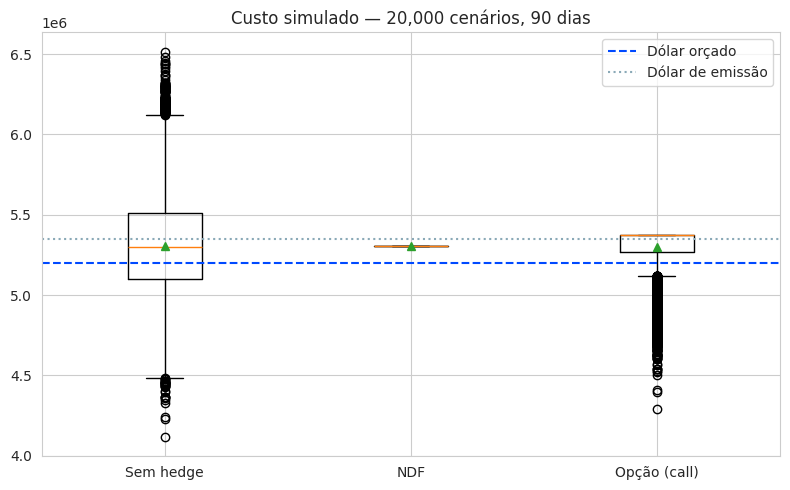

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot([custo_sem_hedge, custo_ndf, custo_opcao], labels=['Sem hedge', 'NDF', 'Opção (call)'], showmeans=True)
plt.axhline(valor_estoque_usd * dolar_orcamento, color='#0049FF', linestyle='--', label='Dólar orçado')
plt.axhline(valor_estoque_usd * dolar_emissao, color='#8AA9B7', linestyle=':', label='Dólar de emissão')
plt.title(f'Custo simulado — {n_sim:,} cenários, {prazo_dias} dias')
plt.legend()
plt.tight_layout()
plt.show()


**Leitura (sem indicar automaticamente "a melhor"):** sem hedge tem a maior variância — pode sair mais barato ou mais caro, dependendo de qual caminho o câmbio realmente seguir. NDF trava o custo, sem variância nenhuma, mas também sem upside se o dólar cair. A opção paga um prêmio fixo hoje pra manter esse upside, com um teto de custo lá em cima.

Rodando os 20 mil cenários, o que mais chama atenção não é a média — é a variância. O NDF trava em `R$ 5.304.297,15` e não sai dali, P95 e P5 idênticos, porque é literalmente isso que ele faz: troca incerteza por um número fixo. A opção fica com custo médio um pouco acima (`R$ 5.326.598,78`), e o prêmio que eu paguei hoje age como um teto — no pior cenário (P95) ela custa `R$ 5.372.778,79`, só cerca de `R$ 68 mil` a mais que o NDF travado, mas se o dólar cair eu ainda pego o P5 mais baixo dos três (`R$ 5.081.978,33`). Sem hedge é onde a coisa abre de verdade: do melhor cenário (`R$ 4.909.199,53`) até o pior (`R$ 5.927.947,57`) tem quase `R$ 1,02 milhão` de diferença, mais que o dobro do intervalo P95-P5 da opção.

Não saiu nenhuma estratégia "vencedora" desse exercício, e isso é o esperado — hedge não é sobre acertar o lado, é sobre quanto de variância eu estou disposta a carregar. Quem precisa de previsibilidade absoluta pro orçamento (não pode estourar o dólar orçado de jeito nenhum) trava no NDF. Quem topa pagar um prêmio pequeno hoje pra manter alguma flexibilidade caso o câmbio caia, vai de opção. Sem hedge só faz sentido se a empresa aguenta absorver a variância inteira — o que, na prática, quase nunca é o caso.


In [ ]:
def simular_decisao_hedge(valor_estoque_usd, prazo_dias, dolar_orcamento, dolar_emissao,
                            taxa_selic=taxa_selic, taxa_fed=taxa_fed, spot=spot_atual,
                            vol=vol_hist, p_alta_modelo=p_alta_modelo, n_sim=20000, seed=SEED):
    T = prazo_dias / 365
    f_ndf = taxa_ndf(spot, taxa_selic, taxa_fed, T)
    strike = dolar_orcamento
    premio_tot = premio_call_gk(spot, strike, taxa_selic, taxa_fed, vol, T) * valor_estoque_usd

    np.random.seed(seed)
    dias_uteis = int(prazo_dias * (252 / 365))
    daily_vol = vol / np.sqrt(252)
    drift = (taxa_selic - taxa_fed) / 252 + (p_alta_modelo - 0.5) * 2 * daily_vol
    Z = np.random.normal(size=(n_sim, dias_uteis))
    S_T_sim = spot * np.exp(((drift - 0.5 * daily_vol**2) + daily_vol * Z).cumsum(axis=1)[:, -1])

    c_sem = valor_estoque_usd * S_T_sim
    c_ndf = np.full(n_sim, valor_estoque_usd * f_ndf)
    c_opc = valor_estoque_usd * np.minimum(S_T_sim, strike) + premio_tot

    return pd.DataFrame({
        'Estratégia': ['Sem hedge', 'NDF', 'Opção (call)'],
        'Custo médio esperado (R$)': [c_sem.mean(), c_ndf.mean(), c_opc.mean()],
        'Pior cenário P95 (R$)': [np.percentile(c_sem, 95), np.percentile(c_ndf, 95), np.percentile(c_opc, 95)],
    })

# outro cenário, só pra testar
simular_decisao_hedge(valor_estoque_usd=2_500_000, prazo_dias=180, dolar_orcamento=5.25, dolar_emissao=5.40)


,Estratégia,Custo médio esperado (R$),Pior cenário P95 (R$)
0,Sem hedge,"13,621,387.74","15,534,999.79"
1,NDF,"13,612,579.21","13,612,579.21"
2,Opção (call),"13,565,407.46","13,793,896.67"
